# Monte Carlo Stock Price Simulation Analysis

## Introduction

This project implements a Monte Carlo simulation framework to model stock price movements using the Wiener process (geometric Brownian motion). The simulation analyzes five major tech stocks (AAPL, GOOGL, NVDA, AMZN, UBER) over a 4+ year period, generating probabilistic price paths to understand potential 1 year future outcomes and risk profiles.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tickers = ["AAPL", "GOOG", "NVDA", "AMZN", "UBER"]
start_date = '2021-01-01'
end_date = '2025-09-25'
T = 1.0
dt = 1 / 252
all_simulations = {}

## Key Technical Implementation

**Wiener Process Model**: The core uses the stochastic differential equation:
```
dS = μS*dt + σS*dW
```
Where:
- S = current stock price at time t
- dS = infinitesimal change in stock price
- μ (mu) = drift rate (annualized expected return), estimated from historical log returns
- σ (sigma) = volatility (annualized standard deviation of returns), estimated from historical log returns
- dt = infinitesimal time increment
- dW = random increment from a Wiener process (standard normal distribution with mean 0 and variance dt)

**Risk Assessment**: The code evolves from single-path visualization to 100-simulation ensembles with confidence bands (5th-95th percentiles), providing a realistic range of potential outcomes.

### Functions

In [3]:
def get_stock_data(ticker, start_date, end_date):
    stock = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)
    return stock['Adj Close']

In [4]:
def wiener_process(S0, mu, sigma, T, dt):
    N = int(T / dt)
    t = np.linspace(0, T, N)
    W = np.random.standard_normal(size=N)
    W = np.cumsum(W) * np.sqrt(dt)
    X = (mu - 0.5 * sigma**2) * t + sigma * W
    S = S0 * np.exp(X)
    return t, S

### Single Simulation

In [5]:
# Basic simulation loop

for ticker in tickers:

    # Setup:
    stock_data = get_stock_data(ticker, start_date, end_date)
    log_returns = np.log(stock_data / stock_data.shift(1)).dropna()

    mu = (log_returns.mean() * 252).item()
    sigma = (log_returns.std() * np.sqrt(252)).item()

    S0 = stock_data.iloc[-1].item()

    # Run simulation
    t, S = wiener_process(S0, mu, sigma, T, dt)

    # Store data
    all_simulations[ticker] = S
    all_time = t

    # DataFrame creation and printing
    simulated_df = pd.DataFrame({
        'Time': t,
        'Simulated Price': S,
        'Initial Price (S0)': S0,
        'Drift (mu)': mu,
        'Volatility (sigma)': sigma
    })

    exec(f"simulated_{ticker} = simulated_df")

    print(f"Created DataFrame for {ticker}:")
    print(simulated_df.head())

[*********************100%***********************]  1 of 1 completed


Created DataFrame for AAPL:
       Time  Simulated Price  Initial Price (S0)  Drift (mu)  \
0  0.000000       254.098153          252.309998    0.147378   
1  0.003984       247.996002          252.309998    0.147378   
2  0.007968       251.758613          252.309998    0.147378   
3  0.011952       259.874319          252.309998    0.147378   
4  0.015936       257.236316          252.309998    0.147378   

   Volatility (sigma)  
0            0.282544  
1            0.282544  
2            0.282544  
3            0.282544  
4            0.282544  


[*********************100%***********************]  1 of 1 completed


Created DataFrame for GOOG:
       Time  Simulated Price  Initial Price (S0)  Drift (mu)  \
0  0.000000       237.126699          247.830002     0.22532   
1  0.003984       231.186239          247.830002     0.22532   
2  0.007968       232.392269          247.830002     0.22532   
3  0.011952       222.992841          247.830002     0.22532   
4  0.015936       224.087335          247.830002     0.22532   

   Volatility (sigma)  
0            0.310874  
1            0.310874  
2            0.310874  
3            0.310874  
4            0.310874  


[*********************100%***********************]  1 of 1 completed


Created DataFrame for NVDA:
       Time  Simulated Price  Initial Price (S0)  Drift (mu)  \
0  0.000000       173.059572          176.970001    0.553527   
1  0.003984       174.610524          176.970001    0.553527   
2  0.007968       175.556562          176.970001    0.553527   
3  0.011952       176.824859          176.970001    0.553527   
4  0.015936       186.037493          176.970001    0.553527   

   Volatility (sigma)  
0            0.525953  
1            0.525953  
2            0.525953  
3            0.525953  
4            0.525953  


[*********************100%***********************]  1 of 1 completed


Created DataFrame for AMZN:
       Time  Simulated Price  Initial Price (S0)  Drift (mu)  \
0  0.000000       228.396223          220.210007    0.068757   
1  0.003984       230.380009          220.210007    0.068757   
2  0.007968       225.055480          220.210007    0.068757   
3  0.011952       230.105912          220.210007    0.068757   
4  0.015936       228.783939          220.210007    0.068757   

   Volatility (sigma)  
0            0.352942  
1            0.352942  
2            0.352942  
3            0.352942  
4            0.352942  


[*********************100%***********************]  1 of 1 completed

Created DataFrame for UBER:
       Time  Simulated Price  Initial Price (S0)  Drift (mu)  \
0  0.000000        99.330087           97.779999    0.137719   
1  0.003984       101.025520           97.779999    0.137719   
2  0.007968        97.691552           97.779999    0.137719   
3  0.011952        98.797501           97.779999    0.137719   
4  0.015936       102.448339           97.779999    0.137719   

   Volatility (sigma)  
0            0.466166  
1            0.466166  
2            0.466166  
3            0.466166  
4            0.466166  


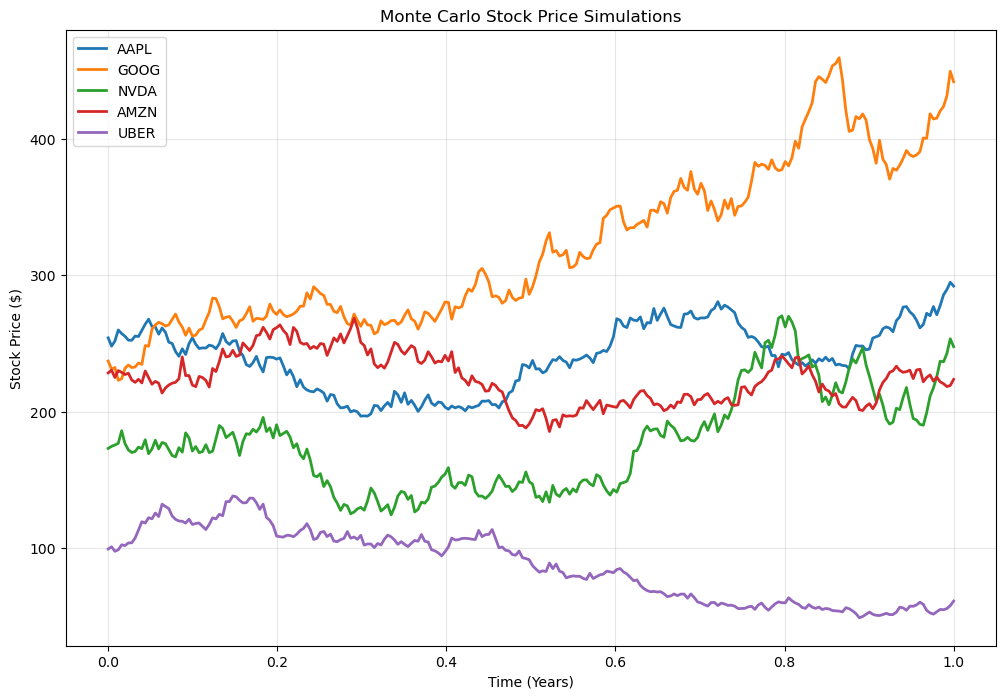

In [15]:
# Single Simulation Viz

plt.figure(figsize=(12, 8))
for ticker in tickers:
    plt.plot(all_time, all_simulations[ticker], label=ticker, linewidth=2)

plt.xlabel('Time (Years)')
plt.ylabel('Stock Price ($)')
plt.title('Monte Carlo Stock Price Simulations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Multiple Simulations

In [7]:
# 100-simulation loop

num_simulations = 100
all_paths = {ticker: [] for ticker in tickers}

for ticker in tickers:
    stock_data = get_stock_data(ticker, start_date, end_date)
    log_returns = np.log(stock_data / stock_data.shift(1)).dropna()
    
    mu = (log_returns.mean() * 252).item()
    sigma = (log_returns.std() * np.sqrt(252)).item()
    S0 = stock_data.iloc[-1].item()
    
    for _ in range(num_simulations):
        t, S = wiener_process(S0, mu, sigma, T, dt)
        all_paths[ticker].append(S)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [8]:
# Confidence band calculations

confidence_data = {}

for ticker in tickers:
    paths_array = np.array(all_paths[ticker])
    
    # Calculate percentiles for confidence bands
    p50 = np.percentile(paths_array, 50, axis=0)
    p05 = np.percentile(paths_array, 5, axis=0)
    p95 = np.percentile(paths_array, 95, axis=0)

    # Store all calculations
    confidence_data[ticker] = {
        'median': p50,
        'p05': p05,
        'p95': p95,
        'paths_array': paths_array
    }

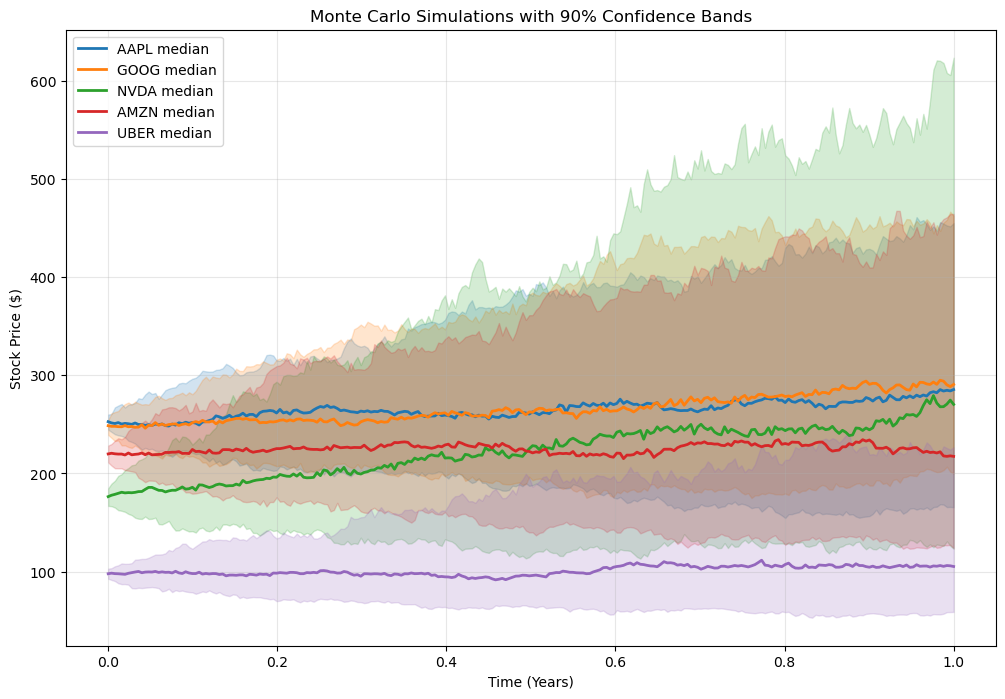

In [14]:
# Combained plot

plt.figure(figsize=(12, 8))
colors = {} 

for i, ticker in enumerate(tickers):
    data = confidence_data[ticker]
    line, = plt.plot(t, data['median'], label=f'{ticker} median', linewidth=2)
    colors[ticker] = line.get_color()  # Save the color
    plt.fill_between(t, data['p05'], data['p95'], alpha=0.2, color=colors[ticker])
    
plt.xlabel('Time (Years)')
plt.ylabel('Stock Price ($)')
plt.title('Monte Carlo Simulations with 90% Confidence Bands')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

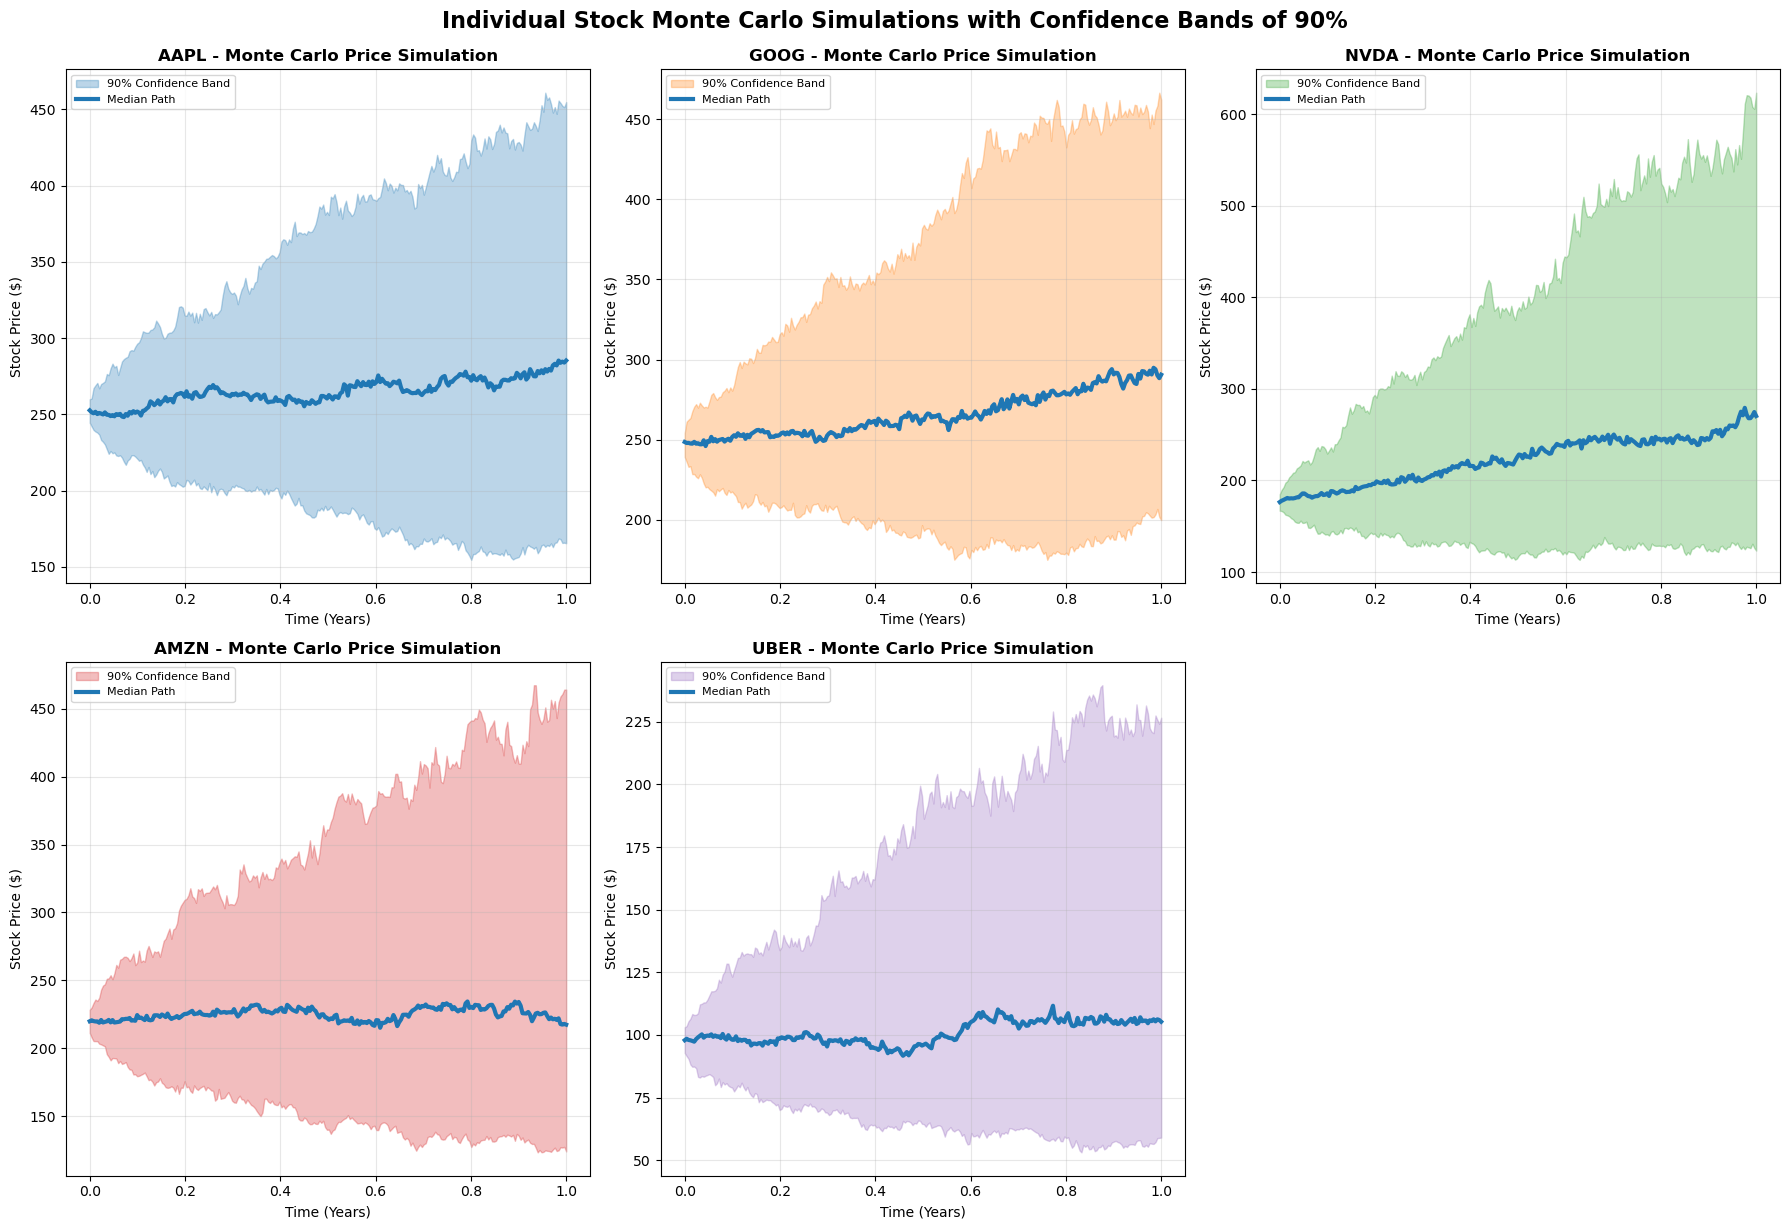

In [11]:
# Individual subplots for detailed analysis

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    data = confidence_data[ticker]
    
    ax.fill_between(t, data['p05'], data['p95'], alpha=0.3, color=colors[ticker], label='90% Confidence Band')
    ax.plot(t, data['median'], linewidth=3, label='Median Path')
    
    ax.set_title(f'{ticker} - Monte Carlo Price Simulation', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (Years)')
    ax.set_ylabel('Stock Price ($)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[5].remove()

plt.tight_layout()
plt.suptitle('Individual Stock Monte Carlo Simulations with Confidence Bands of 90%', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [19]:
# Print summary statistics

for ticker in tickers:
    data = confidence_data[ticker]
    initial_price = data['paths_array'][0, 0]  # Starting price
    final_median = data['median'][-1]
    final_p05 = data['p05'][-1]
    final_p95 = data['p95'][-1]
    
    print(f"\n{ticker}:")
    print(f"  Initial Price: ${initial_price:.2f}")
    print(f"  Final Median:  ${final_median:.2f} ({((final_median/initial_price-1)*100):+.1f}%)")
    print(f"  90% Confidence Interval: ${final_p05:.2f} to ${final_p95:.2f}")
    print(f"  Risk Spread:   ${final_p95-final_p05:.2f} ({((final_p95-final_p05)/final_median*100):.1f}% of median)")


AAPL:
  Initial Price: $260.39
  Final Median:  $285.37 (+9.6%)
  90% Confidence Interval: $165.58 to $454.86
  Risk Spread:   $289.28 (101.4% of median)

GOOG:
  Initial Price: $247.72
  Final Median:  $290.57 (+17.3%)
  90% Confidence Interval: $199.84 to $462.24
  Risk Spread:   $262.40 (90.3% of median)

NVDA:
  Initial Price: $180.13
  Final Median:  $270.30 (+50.1%)
  90% Confidence Interval: $123.38 to $623.27
  Risk Spread:   $499.89 (184.9% of median)

AMZN:
  Initial Price: $213.51
  Final Median:  $217.38 (+1.8%)
  90% Confidence Interval: $124.00 to $464.16
  Risk Spread:   $340.15 (156.5% of median)

UBER:
  Initial Price: $96.66
  Final Median:  $105.27 (+8.9%)
  90% Confidence Interval: $59.02 to $226.66
  Risk Spread:   $167.65 (159.3% of median)


## Key Insights

**Risk Profile Comparison**: The simulation reveals dramatically different risk profiles across the five tech stocks over a 1-year horizon. 
- NVDA exhibits the highest volatility (52.6% sigma) and widest risk spread (184.9% of median), making it the most unpredictable.
- AAPL and GOOG show more moderate volatility (~28-31% sigma) with tighter confidence bands, suggesting more stable price trajectories.
- AMZN falls into a problematic middle ground with moderate-to-high volatility (35.3% sigma) and a 156.5% risk spread, but couples this risk with the lowest expected return (+1.8%), creating an unfavorable risk-reward asymmetry.

**Return Expectations**: The median projected returns vary significantly: AAPL (+9.6%), GOOG (+17.3%), NVDA (+50.1%), AMZN (+1.8%), and UBER (+8.9%). However, these medians tell only part of the story — the 90% confidence intervals reveal enormous uncertainty for NVDA (5x spread), which makes it rather speculative. On the contrary GOOG with is rather a defensive stock (2,3x spread)

**Downside Risk Assessment**: The 5th percentile values are critical for risk management. AAPL could fall to $165  (36% downside), while NVDA could drop to 123 dollars (32% downside). UBER shows the tightest downside protection, with only 39% drop potential in the worst 5% of scenarios.

## Practical Applications

**Portfolio Risk Management**: The risk spread metric allows you to scale position sizes inversely to volatility. By weighting positions based on their confidence intervals relative to your portfolio's target volatility, you can construct diversified exposure where no single position dominates total portfolio risk.

**Options Strategy Selection**: The wide confidence intervals for NVDA and AMZN suggest profitable opportunities for volatility-based strategies (selling strangles, iron condors). Conversely, the tighter bands for AAPL and GOOG indicate lower option premiums but more predictable outcomes.

**Stop-Loss Calibration**: Use the 5th percentile values to set informed stop-losses. Setting stops tighter than these levels means you'll likely be stopped out even in normal market conditions. The p05 values represent statistically-driven floor levels for each position.


## Conclusion

This Monte Carlo framework provides a solid foundation for understanding stock price uncertainty and risk through geometric Brownian motion. The model assumes **constant drift and volatility parameters** throughout the simulation period - meaning each stock's growth rate and risk level remain fixed based on historical averages.

**Production Extensions**: For more sophisticated analysis, it is recomended to consider:
- **Stochastic volatility models** (like Heston) where volatility itself fluctuates randomly
- **Regime-switching dynamics** that account for different market conditions (bull vs bear markets with distinct risk-return profiles)
- **Jump-diffusion processes** to capture sudden price movements from earnings or news events

While these extensions add mathematical complexity, the current model's probabilistic approach already provides valuable insights for portfolio risk management, scenario planning, and understanding the range of potential investment outcomes.